## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 4: Regularización — Ridge, Lasso y Elastic Net**

Andrés C. Medina Sanhueza  
Senior Data Scientist Engineer  
anmedinas@gmail.com

---

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import lasso_path
from matplotlib.patches import Patch
from sklearn.base import clone
import scipy.stats as stats
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import yfinance as yf

# Configuraciones
warnings.filterwarnings('ignore')
sns.set_style('dark')

# Semilla para reproducibilidad
np.random.seed(20260527)

## 🍁 **`Introducción`**

Una **`señal`** es el componente de los datos que contiene información real y predecible, el patrón que un modelo puede aprender y generalizar. En términos matemáticos, es la parte sistemática de los datos:

\begin{equation*}
\text{señal} = f(x_t) = \mathbb{E}[y_t \mid x_t]
\end{equation*}

En finanzas, la señal es todo lo que es predecible a partir de información pasada: momentum, reversión a la media, factores de riesgo. Es pequeña, persistente, y difícil de detectar. Por otro lado, el **`ruido`** es la parte aleatoria e impredecible de los datos, fluctuaciones que no siguen ningún patrón y que no pueden anticiparse con ningún modelo:

\begin{equation*}
\varepsilon_t \sim \mathcal{N}(0, \sigma^2_\varepsilon) \quad \text{independiente de } x_t
\end{equation*}

En finanzas, el ruido es la volatilidad estocástica diaria, noticias inesperadas, flujos de liquidez aleatorios. Es grande, dominante, e irreducible.

Todo lo que observamos es una mezcla de ambos:

\begin{equation*}
\underbrace{y_t}_{\text{observado}} = \underbrace{f(x_t)}_{\text{señal verdadera}} + \underbrace{\varepsilon_t}_{\text{ruido}}
\end{equation*}

El problema del aprendizaje supervisado es precisamente separar $f(x_t)$ de $\varepsilon_t$ usando solo $y_t$.

<tr>
<td><img src="../figs/figura_014.png" align="middle" style="width: 1000px;"/> </td>
</tr>

En este contexto, **SNR** (Signal-to-Noise Ratio), mide cuánto de lo que observamos es señal vs ruido

\begin{equation*}
\texttt{SNR} = \frac{\sigma^2_{\text{señal}}}{\sigma^2_{\text{ruido}}} = \frac{\text{Var}(f(x_t))}{\text{Var}(\varepsilon_t)}
\end{equation*}

Algunas consideraciones sobre **SNR**:

* $\texttt{SNR} \gg 1$ la señal es la que domina, por ende el modelo aprende facilmente.
* $\texttt{SNR} = 1$ existe un balance entre señal y ruido, por ende en la estimacion del modelo, hay que tener cierta precaucion.
* $\texttt{SNR} \ll 1$ el ruido es el que domina y las consecuencias, son que es muy fácil de sobreajustar el modelo.

En el contexto financiero, los retornos diarios de activos financieros tienen $\texttt{SNR}$ extremadamente bajo. Un ejemplo típico para el S&P 500:

* Drift diario: $\mu \approx 0.04%$ (~10% anual / 252 días)
* Volatilidad diaria: $\sigma \approx 1.2%$ (~19% anual)

\begin{equation*}
\text{SNR} = \left(\frac{\mu}{\sigma}\right)^2 = \left(\frac{0.0004}{0.012}\right)^2 \approx 0.001
\end{equation*}

El ruido tiene 900 veces más varianza que la señal. Esto significa que un modelo sin restricciones (como el OLS) casi inevitablemente aprende ruido en lugar de señal

En este contexto, cuando el $\texttt{SNR}$ es bajo, el modelo de machine learning, enfrenta un dilema.

* Sin regularización (OLS): ajusta perfectamente el train, pero lo que ajusta es mayoritariamente ruido (mala generalización)

* Con regularización (Ridge/Lasso): sacrifica algo de ajuste en train para no perseguir el ruido (mejor generalización OOT)

## 🎖️ **`Motivación`**

### ¿Por qué *regularizar* en Finanzas?

En finanzas cuantitativa, el problema de predicción tiene características que lo hacen especialmente difícil:

| Desafío | Consecuencia para ML |
|---------|---------------------|
| **Señales débiles** (bajo SNR) | Fácil sobreajustar ruido |
| **Features correlacionadas** (lags, rollings) | $X^\top X$ mal condicionada, por ende, OLS inestable |
| **No estacionariedad** | Parámetros cambian entre regímenes |
| **Objetivo OOT** | Queremos generalizar al futuro, no explicar el pasado |

> **Regularización = controlar la complejidad del modelo para mejorar la generalización futura (OOT)**

📌 La regularización es esencialmente un mecanismo para decirle al modelo: `no confíes tanto en los datos de entrenamiento, porque la mayor parte de lo que ves es ruido`

Sea $p$ el número de features. Cuando $p$ es grande o hay multicolinealidad alta, OLS:
- Tiene varianza alta (overfitting)
- Produce coeficientes muy grandes e inestables
- En casos extremos ($p > T$), no está definida sin regularización

🖍️ **`Solución`** añadir una penalización que encoge o elimina coeficientes según la evidencia de los datos.

## 📚 **`Marco General: Riesgo Empírico`**

La pregunta que cabe hacerse, dado los antecedentes anteriores es: ¿Qué tan bien predice mi modelo en datos que no he visto?. Consideremos un dataset temporal $\{(x_t, y_t)\}_{t=1}^T$ con $x_t \in \mathbb{R}^p$ donde cada $y_t$ (retornos, volatilidades, spreads, etc) es lo que observamos, y las $x_t$ son las variables con la que intentamos predecir. La realidad que genera estos datos es:

\begin{equation*}
y_t = \underbrace{\beta_0 + x_t^\top\beta^*}_{\text{señal}} + \varepsilon_t
\end{equation*}

$\beta^*$ existe pero es desconocido. El ruido $\varepsilon_t$ también existe y es irreducible. Nuestro único acceso a $\beta^*$ es a través de los $T$ pares $(x_t, y_t)$, en finanzas, ese acceso es ruidoso porque el SNR es muy bajo.

Lo que queremos minimizar es el riesgo verdadero, el error esperado sobre cualquier dato futuro:

\begin{equation*}
R(\beta) = \mathbb{E}\left[\ell\!\left(y,\beta_0 + x^\top\beta\right)\right]
\end{equation*}

---

🖍️ **`Nota`** $\ell$ es la función de pérdida (ó *loss function*). Es la función que mide cuánto se equivoca la predicción $\hat{y} = \beta_0 + x^\top\beta$ respecto al valor real $y$.

\begin{equation*}
\ell : \mathbb{R} \times \mathbb{R} \to \mathbb{R}_{\geq 0}
\end{equation*}

Siempre cumple $\ell(y, \hat{y}) \geq 0$ y $\ell(y, y) = 0$ sin error, pérdida nula.

---

Lo que podemos calcular es el riesgo empírico, el error promedio sobre los $T$ datos de entrenamiento:

\begin{equation*}
\widehat{R}(\beta) = \frac{1}{T}\sum_{t=1}^T \ell\!\left(y_t,\, \beta_0 + x_t^\top\beta\right)
\end{equation*}

Estas dos cantidades no son iguales. $\widehat{R}(\beta)$ es una estimación de $R(\beta)$, y como toda estimación, tiene error. Ese error tiene consecuencias directas sobre lo que aprendemos.

Si minimizamos $\hat{R}$ sin restricción (que es exactamente lo que hace OLS), obtenemos un modelo que es óptimo para los datos de train, pero no necesariamente para datos futuros. ¿Por qué? , porque $\widehat{R}$ contiene tanto la señal como el ruido de entrenamiento. Un modelo suficientemente flexible puede reducir $\widehat{R}$ ajustando el ruido $\varepsilon_t$ de los datos de train, correlaciones que son completamente espurias y que no aparecerán en datos nuevos.

La magnitud de ese problema no es aleatoria, depende de cuántos parámetros tiene el modelo y de cuánto ruido hay en los datos:

\begin{equation*}
R(\hat\beta) - \hat{R}(\hat\beta) \approx \frac{p \cdot \sigma^2_\varepsilon}{T} = \frac{p}{T \cdot \texttt{SNR}}
\end{equation*}

En finanzas, el SNR es muy bajo y $p$ suele ser grande en relación a $T$. El gap entre riesgo empírico y riesgo verdadero puede ser enorme y OLS lo ignora completamente.

Si el problema es que $\widehat{R}$ subestima $R$ en una cantidad proporcional a la complejidad del modelo, la solución natural es penalizar esa complejidad directamente en el objetivo:

\begin{equation*}
\min_{\beta_0,\, \beta} \;\; \frac{1}{T}\sum_{t=1}^T \ell\!\left(y_t,\, \beta_0 + x_t^\top\beta\right) + \lambda\,\Omega(\beta)
\end{equation*}

Este es el riesgo empírico penalizado. El término $\Omega(\beta)$ mide la complejidad del modelo, y $\lambda > 0$ controla cuánto peso le damos a esa penalización. El problema de minimizar $\widehat{R}$ solo se corrige añadiendo esta restricción implícita sobre $\beta$. La elección de $\Omega(\beta)$ determina el método. Con pérdida cuadrática, las más usadas son:

| Método | $\Omega(\beta)$ | Propiedad clave |
|--------|----------------|----------------|
| Ridge | $\|\beta\|_2^2 = \sum_j \beta_j^2$ | Encoge todos los coeficientes |
| Lasso | $\|\beta\|_1 = \sum_j\vert\beta_j\vert$| Selección automática (sparsidad) |
| Elastic Net | $\alpha\|\beta\|_1 + (1-\alpha)\|\beta\|_2^2$ | Selección + estabilidad |

Los tres atacan el mismo gap $\frac{p}{T \cdot \text{SNR}}$, pero con distinta filosofía:

* **`Ridge`** reduce el gap achicando la magnitud de los coeficientes, ninguno llega a cero, todos encogen
* **`Lasso`** reduce el gap achicando directamente $p$, si un coeficiente no está justificado por la señal, lo elimina
* **`Elastic Net`** hace ambas cosas, útil cuando hay features correlacionadas, que es lo habitual en finanzas

Ahora, esto, tiene un costo. Penalizar $\Omega(\beta)$ no es gratis. El error de test se descompone como:

\begin{equation*}
\text{Error}_{\text{test}} = \underbrace{\text{Sesgo}^2}_{\uparrow\lambda} + \underbrace{\text{Varianza}}_{\downarrow\lambda} + \underbrace{\sigma^2\varepsilon}_{\text{irreducible}}
\end{equation*}

Al aumentar $\lambda$:

* Los coeficientes se encogen más, el modelo se aleja de $\beta^*$, por tanto el sesgo sube
* El modelo depende menos del ruido de train, la varianza baja
* El ruido irreducible $\sigma^2_\varepsilon$ no cambia con ningún $\lambda$, es el piso mínimo de error
  
📌 El $\lambda^*$ óptimo está donde la ganancia marginal en varianza iguala la pérdida marginal en sesgo. Ese punto no se conoce analíticamente — se estima por validación cruzada temporal 

## 🦊 Ridge Regression

### Formulación

Sea $y \in \mathbb{R}^T$, $X \in \mathbb{R}^{T \times p}$ centrados:

\begin{equation*}
\min_{\beta}\; \|y - X\beta\|_2^2 + \lambda\|\beta\|_2^2
\end{equation*}

Si expandimos la función objetivo (matricialmente), tenemos:

\begin{align*}
f(\beta) &= (y - X\beta)^\top(y - X\beta) + \lambda\beta^\top\beta \\
        &= y^\top y - 2\beta^\top X^\top y + \beta^\top X^\top X\beta + \lambda\beta^\top\beta
\end{align*}

Por condiciones de primer orden (CPO), tenemos 

\begin{align*}
\frac{\partial f}{\partial \beta} &= -2X^\top(y - X\beta) + 2\lambda\beta = 0 \\
& \rightarrow X^\top X\hat\beta + \lambda\hat\beta = X^\top y \\
& \rightarrow (X^\top X + \lambda I)\hat\beta = X^\top y \\
& \rightarrow\hat\beta_{\text{ridge}} = (X^\top X + \lambda I)^{-1}X^\top y
\end{align*}


📌 **Clave:** $(X^\top X + \lambda I)$ siempre es invertible pues sus autovalores son $\sigma_i^2 + \lambda > 0$, incluso cuando $X^\top X$ es singular o $p > T$.

Dif. maxima formula manual vs sklearn: 2.22e-16


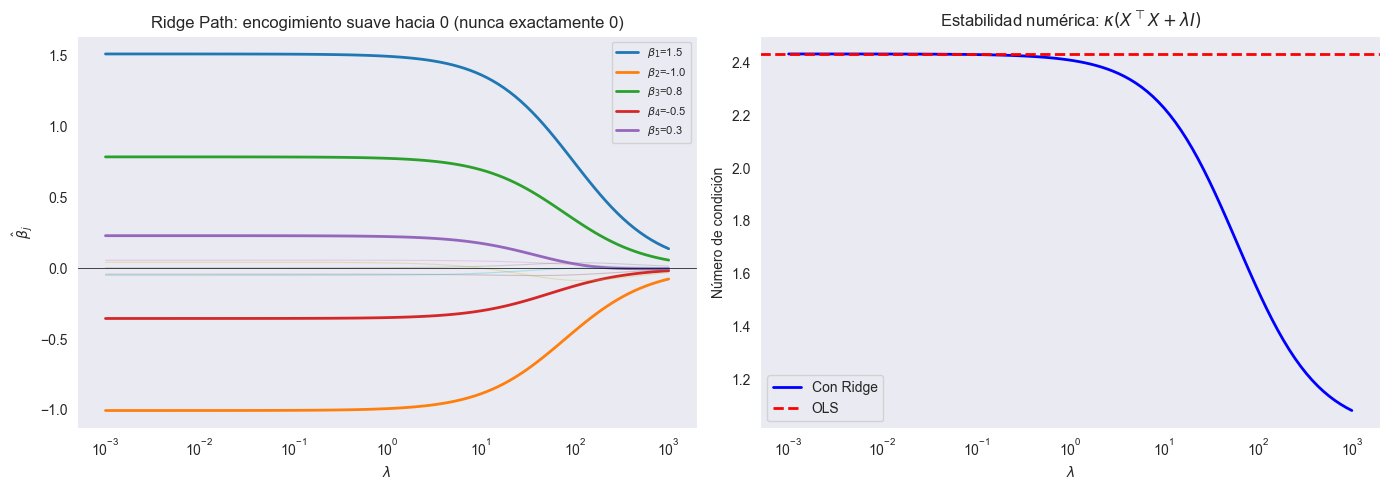

In [15]:
# Ilustracion 
np.random.seed(0)
T2, p2 = 100, 10

# Matriz Aleartoria de T2xp2
X2 = np.random.randn(T2, p2)

# Valores de los beta con algunos ceros para simular sparsity
beta2 = np.array([1.5, -1, 0.8, -0.5, 0.3, 0, 0, 0, 0, 0])

# Generamos la variable dependiente con algo de ruido
y2 = X2 @ beta2 + 0.5 * np.random.randn(T2)

# Fórmula cerrada para Ridge
def ridge_closed_form(X, y, lam):
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)

# Comparación con sklearn
lam_test = 1.0
b_manual = ridge_closed_form(X2, y2, lam_test)
b_sklearn = Ridge(alpha=lam_test, fit_intercept=False).fit(X2, y2).coef_
print(f"Dif. maxima formula manual vs sklearn: {np.max(np.abs(b_manual - b_sklearn)):.2e}")

# Ridge path
lambdas2 = np.logspace(-3, 3, 100)
coef_path = np.array([ridge_closed_form(X2, y2, l) for l in lambdas2])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for j in range(p2):
    lw = 2.0 if beta2[j] != 0 else 0.8
    alpha = 1.0 if beta2[j] != 0 else 0.3
    label = f'$\\beta_{j+1}$={beta2[j]}' if beta2[j] != 0 else None
    ax1.plot(lambdas2, coef_path[:, j], lw=lw, alpha=alpha, label=label)

ax1.axhline(0, color='k', lw=0.5)
ax1.set_xscale('log')
ax1.set_xlabel(r'$\lambda$'); ax1.set_ylabel(r'$\hat\beta_j$')
ax1.set_title('Ridge Path: encogimiento suave hacia 0 (nunca exactamente 0)')
ax1.legend(fontsize=8)

# Número de condición
conds = [np.linalg.cond(X2.T @ X2 + l * np.eye(p2)) for l in lambdas2]
ax2.semilogx(lambdas2, conds, 'b-', lw=2, label='Con Ridge')
ax2.axhline(np.linalg.cond(X2.T @ X2), color='red', ls='--', lw=2, label='OLS')
ax2.set_xlabel(r'$\lambda$'); ax2.set_ylabel('Número de condición')
ax2.set_title(r'Estabilidad numérica: $\kappa(X^\top X + \lambda I)$')
ax2.legend()

plt.tight_layout(); plt.show()

El panel izquierdo muestra el *Ridge path*: la evolución de los coeficientes $\hat{\beta}_j$ en función de $\lambda$. Para $\lambda \to 0$ los coeficientes convergen a la solución OLS; al aumentar $\lambda$ todos se encogen suavemente hacia cero, sin anularse exactamente, propiedad característica de la penalización  $\ell_2$. El panel derecho muestra el número de condición $\kappa(X^\top X + \lambda I)$: a medida que $\lambda$ crece, la matriz del sistema se vuelve progresivamente mejor condicionada respecto a OLS (línea roja),  garantizando invertibilidad incluso bajo multicolinealidad. Ambos paneles ilustran el rol dual de $\lambda$: controla simultáneamente el encogimiento de los coeficientes y la estabilidad numérica de la estimación.


## 🦜 Lasso Regression

### Formulación

\begin{equation*}
\min_{\beta}\; \frac{1}{2}\|y - X\beta\|_2^2 + \lambda\|\beta\|_1, \quad \|\beta\|_1 = \sum_{j=1}^p |\beta_j|
\end{equation*}

### ¿Por qué no existe solución cerrada?

Con pérdida cuadrática, el objetivo Lasso es la suma de dos términos:

\begin{equation*}
\min_{\beta}\; \underbrace{\frac{1}{2}\|y - X\beta\|_2^2}_{g(\beta)\text{ — diferenciable}} + \underbrace{\lambda\|\beta\|_1}_{\text{no diferenciable en }\beta_j = 0}
\end{equation*}

OLS tiene solución cerrada porque $g(\beta)$ es diferenciable en todo $\mathbb{R}^p$ — basta igualar $\nabla g = 0$. Lasso añade $|\beta_j|$, que **no tiene derivada en $\beta_j = 0$**. No se puede igualar $\nabla = 0$ directamente, por lo que se necesita un marco más general: las condiciones KKT con subgradientes.

### Condiciones de Optimalidad (KKT) — Derivación Completa

**Punto de partida:** $\hat\beta$ es solución si y solo si $0$ pertenece al subgradiente del objetivo:

$$0 \in \partial f(\hat\beta) = \underbrace{-X^\top(y - X\hat\beta)}_{\nabla g(\hat\beta)} + \lambda\,\partial\|\hat\beta\|_1$$

donde la **subderivada** de $|\beta_j|$ es:

$$\partial |\beta_j| = \begin{cases} \{+1\} & \text{si } \beta_j > 0 \\ [-1,\,1] & \text{si } \beta_j = 0 \\ \{-1\} & \text{si } \beta_j < 0 \end{cases}$$

**Condición por coordenada:** expandimos $-X^\top(y - X\beta)$ en la coordenada $j$:

$$\left[-X^\top(y - X\beta)\right]_j = -X_j^\top\!\left(y - X_{-j}\beta_{-j} - X_j\beta_j\right) = -\underbrace{X_j^\top(y - X_{-j}\beta_{-j})}_{r_j} + \underbrace{X_j^\top X_j}_{=\,1}\,\beta_j$$

donde $r_j = X_j^\top(y - X_{-j}\beta_{-j})$ es el **residuo parcial** — la correlación de la feature $j$ con lo que queda de $y$ después de explicar todo con el resto de features. La condición KKT para la coordenada $j$ queda:

$$0 \in -r_j + \beta_j + \lambda\,\partial|\beta_j| \quad\Longleftrightarrow\quad r_j - \beta_j \in \lambda\,\partial|\beta_j|$$

**Caso 1 — $\beta_j > 0$:** $\partial|\beta_j| = \{+1\}$, entonces:

$$r_j - \beta_j = \lambda \quad\Rightarrow\quad \beta_j = r_j - \lambda$$

Consistencia: $\beta_j > 0$ requiere $r_j > \lambda$.

**Caso 2 — $\beta_j < 0$:** $\partial|\beta_j| = \{-1\}$, entonces:

$$r_j - \beta_j = -\lambda \quad\Rightarrow\quad \beta_j = r_j + \lambda$$

Consistencia: $\beta_j < 0$ requiere $r_j < -\lambda$.

**Caso 3 — $\beta_j = 0$:** $\partial|\beta_j| = [-1,+1]$, entonces:

$$r_j \in \lambda\cdot[-1,+1] \quad\Rightarrow\quad |r_j| \leq \lambda$$

No hay nada que resolver — $\beta_j = 0$ es óptimo siempre que el residuo parcial no supere el umbral $\lambda$.

**Reuniendo los tres casos:**

$$\hat\beta_j = \begin{cases} r_j - \lambda & \text{si } r_j > \lambda \\ 0 & \text{si } |r_j| \leq \lambda \\ r_j + \lambda & \text{si } r_j < -\lambda \end{cases}$$

Que se escribe de forma compacta como el **operador soft-threshold**:

$$\hat{\beta}_j = \mathcal{S}_\lambda(r_j) = \operatorname{sign}(r_j)\cdot\max\!\left(|r_j| - \lambda,\; 0\right)$$

> 📌 **Mecanismo de sparsidad:** si $|r_j| \leq \lambda$, la feature $j$ no aporta correlación suficiente con el residuo para justificar $\beta_j \neq 0$ — Lasso la elimina exactamente. $\lambda$ actúa como **umbral de relevancia mínima**.

### Algoritmo: Descenso de Coordenadas

Como la solución cerrada existe por coordenada (no para todo $\beta$ simultáneamente), Lasso se resuelve iterando una coordenada a la vez hasta convergencia:

$$\hat\beta_j \leftarrow \mathcal{S}_\lambda\!\left(\frac{X_j^\top(y - X_{-j}\hat\beta_{-j})}{\|X_j\|^2}\right), \quad j = 1, \ldots, p \quad \text{(repetir hasta convergencia)}$$

En cada paso, $\beta_j$ se actualiza a su valor óptimo dado que todos los demás $\beta_{k \neq j}$ están fijos. La convergencia está garantizada porque el objetivo es convexo.

### Intuición Geométrica L1 vs L2

| Método | Restricción equivalente | Geometría |
|--------|------------------------|-----------|
| Ridge | $\|\beta\|_2^2 \leq t$ | Esfera — sin esquinas |
| Lasso | $\|\beta\|_1 \leq t$ | Diamante — **esquinas sobre los ejes** |

Las esquinas de la bola $\ell_1$ caen exactamente sobre los ejes coordenados ($\beta_j = 0$). La solución al problema restringido tiende a caer en estas esquinas → sparsidad.

### Resumen

| Elemento | Descripción |
|----------|-------------|
| **Por qué no hay solución global cerrada** | $\|\beta\|_1$ no es diferenciable en $\beta_j = 0$ |
| **Herramienta** | Subgradientes + condiciones KKT |
| **$\hat\beta_j$ óptimo** | $\mathcal{S}_\lambda(r_j) = \operatorname{sign}(r_j)\max(\lvert r_j\rvert - \lambda, 0)$ |
| **Mecanismo de sparsidad** | $\hat\beta_j = 0$ exacto cuando $\lvert r_j\rvert \leq \lambda$ |
| **Algoritmo** | Descenso de coordenadas — una coordenada a la vez hasta convergencia |

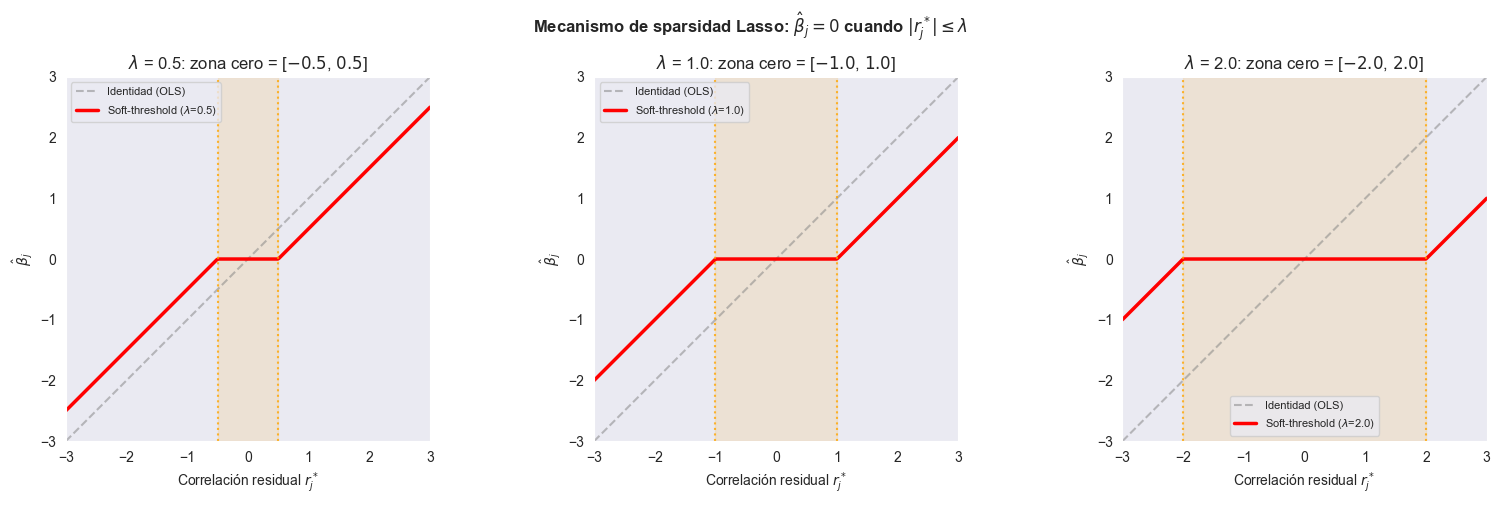

In [16]:
# Operador soft-thresholding y geometría L1 vs L2
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0)

z = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Soft-threshold para distintos lambda
for lam_st, ax in zip([0.5, 1.0, 2.0], axes):
    st = soft_threshold(z, lam_st)
    ax.plot(z, z, color='gray', ls='--', alpha=0.5, label='Identidad (OLS)')
    ax.plot(z, st, 'r-', lw=2.5, label=f'Soft-threshold ($\\lambda$={lam_st})')
    ax.fill_betweenx([-3, 3], -lam_st, lam_st, alpha=0.12, color='orange')
    ax.axvline(-lam_st, color='orange', ls=':', alpha=0.8)
    ax.axvline(lam_st, color='orange', ls=':', alpha=0.8)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_xlabel('Correlación residual $r_j^*$')
    ax.set_ylabel(r'$\hat\beta_j$')
    ax.set_title(f'$\\lambda$ = {lam_st}: zona cero = [$-{lam_st}$, ${lam_st}$]')
    ax.legend(fontsize=8)

plt.suptitle('Mecanismo de sparsidad Lasso: $\\hat\\beta_j = 0$ cuando $|r_j^*| \\leq \\lambda$',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

El gráfico muestra cómo Lasso determina el valor de cada coeficiente $\hat{\beta}_j$ en función de la correlación de la variable $j$ con el residuo del modelo, denotada $r_j$:

* Si la correlación es *débil*, es decir $|r_j| \leq \lambda$, Lasso fija $\hat{\beta}_j = 0$ exactamente y elimina la variable del modelo.

* Si la correlación es *fuerte*, es decir $|r_j| > \lambda$, Lasso mantiene la variable pero encoge su coeficiente en $\lambda$ unidades 

\begin{equation*}
\hat{\beta}_j = \operatorname{sign}(r_j)\cdot(|r_j| - \lambda)
\end{equation*}

A mayor $\lambda$, más amplia es la zona de cero y mayor es el número de variables eliminadas. La línea punteada representa la solución OLS, que no aplica ningún umbral y nunca elimina variables del modelo.


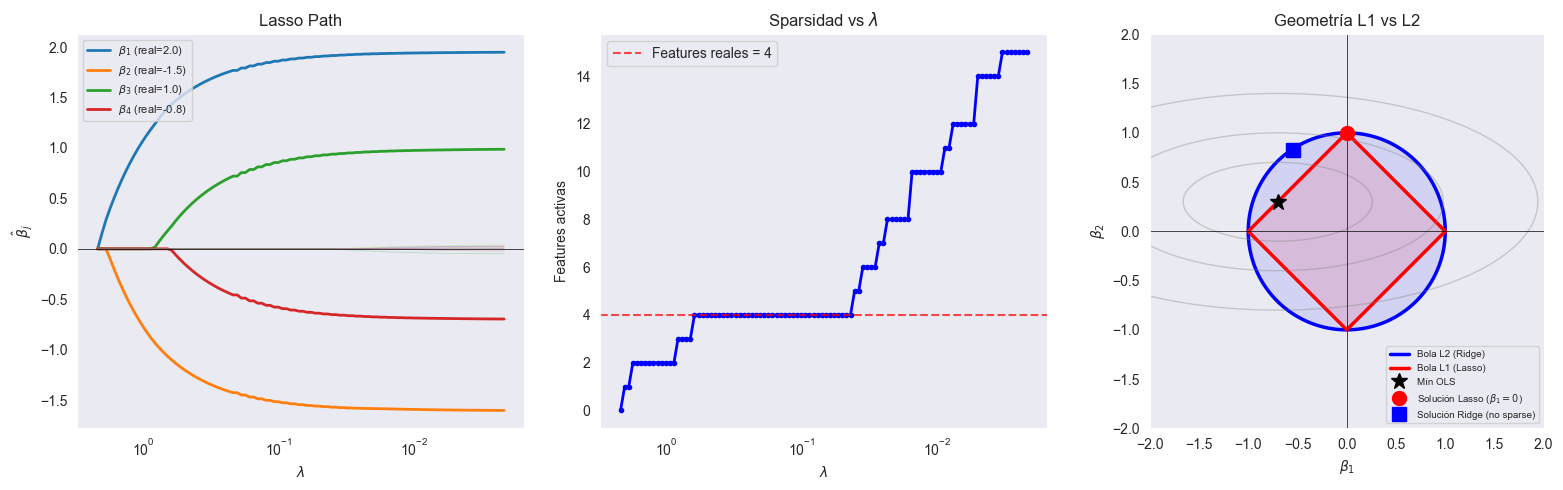

In [17]:
# Lasso regularization path + geometría L1 vs L2
np.random.seed(1)
T3, p3 = 120, 15
X3 = np.random.randn(T3, p3)
beta3 = np.array([2.0, -1.5, 1.0, -0.8] + [0]*11)
y3 = X3 @ beta3 + 0.3 * np.random.randn(T3)
X3s = (X3 - X3.mean(0)) / X3.std(0)

alphas3, coefs3, _ = lasso_path(X3s, y3, n_alphas=100)

fig = plt.figure(figsize=(16, 5))
ax1, ax2, ax3 = fig.add_subplot(131), fig.add_subplot(132), fig.add_subplot(133)

# Lasso path
for j in range(p3):
    lw = 2.0 if beta3[j] != 0 else 0.6
    alpha_l = 1.0 if beta3[j] != 0 else 0.25
    label = f'$\\beta_{j+1}$ (real={beta3[j]})' if beta3[j] != 0 else None
    ax1.semilogx(alphas3, coefs3[j], lw=lw, alpha=alpha_l, label=label)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel(r'$\lambda$'); ax1.set_ylabel(r'$\hat\beta_j$')
ax1.set_title('Lasso Path'); ax1.legend(fontsize=8)
ax1.invert_xaxis()

# Sparsidad
n_nz = np.sum(np.abs(coefs3) > 1e-6, axis=0)
ax2.semilogx(alphas3, n_nz, 'b-o', ms=3, lw=2)
ax2.axhline(4, color='red', ls='--', alpha=0.7, label='Features reales = 4')
ax2.set_xlabel(r'$\lambda$'); ax2.set_ylabel('Features activas')
ax2.set_title('Sparsidad vs $\\lambda$'); ax2.legend(); ax2.invert_xaxis()

# Geometría L1 vs L2
theta = np.linspace(0, 2*np.pi, 300)
# L2
ax3.plot(np.cos(theta), np.sin(theta), 'b-', lw=2.5, label='Bola L2 (Ridge)')
ax3.fill(np.cos(theta), np.sin(theta), alpha=0.1, color='blue')
# L1
bx = [1, 0, -1, 0, 1]; by = [0, 1, 0, -1, 0]
ax3.plot(bx, by, 'r-', lw=2.5, label='Bola L1 (Lasso)')
ax3.fill(bx, by, alpha=0.1, color='red')
# Curvas de nivel objetivo
for lev in [0.8, 1.4, 2.2]:
    ax3.plot(1.2*lev*np.cos(theta) - 0.7, 0.5*lev*np.sin(theta) + 0.3,
             'gray', alpha=0.35, lw=1)
ax3.plot(-0.7, 0.3, 'k*', ms=12, label='Mín OLS')
ax3.plot(0, 1, 'ro', ms=10, zorder=5, label='Solución Lasso ($\\beta_1=0$)')
ax3.plot(-0.55, 0.83, 'bs', ms=10, zorder=5, label='Solución Ridge (no sparse)')
ax3.set_xlim(-2, 2); ax3.set_ylim(-2, 2)
ax3.axhline(0, color='k', lw=0.5); ax3.axvline(0, color='k', lw=0.5)
ax3.set_aspect('equal')
ax3.set_xlabel(r'$\beta_1$'); ax3.set_ylabel(r'$\beta_2$')
ax3.set_title('Geometría L1 vs L2'); ax3.legend(fontsize=7, loc='lower right')

plt.tight_layout(); plt.show()

El gráfico presenta tres perspectivas complementarias del comportamiento de Lasso en función del parámetro de regularización $\lambda$.

* *Panel izquierdo — Lasso Path:* muestra la evolución de los coeficientes $\hat{\beta}_j$ a medida que $\lambda$ decrece (de izquierda a derecha). Para $\lambda$ grande todos los coeficientes son cero; a medida que $\lambda$ disminuye, las variables con mayor correlación con el residuo van ingresando al modelo una a una. Las cuatro variables con coeficiente verdadero distinto de cero ($\beta_1, \beta_2, \beta_3, \beta_4$) son recuperadas progresivamente, mientras las variables irrelevantes permanecen en cero.

* *Panel central — Sparsidad vs $\lambda$:* muestra el número de features activas ($\hat{\beta}_j \neq 0$) en función de $\lambda$. Existe una región donde el modelo selecciona exactamente las 4 variables verdaderas (línea roja punteada), lo que ilustra la capacidad de Lasso para realizar selección automática de variables cuando $\lambda$ se elige correctamente.

* *Panel derecho — Geometría $\ell_1$ vs $\ell_2$:* compara las regiones de restricción de Ridge (bola $\ell_2$, círculo azul) y Lasso (bola $\ell_1$, diamante rojo). Las curvas de nivel grises representan el objetivo OLS. La solución de Lasso (punto rojo) cae en una esquina del diamante donde $\beta_1 = 0$, produciendo sparsidad. La solución de Ridge (cuadrado azul) cae sobre la esfera sin tocar ningún eje, por lo que nunca anula coeficientes exactamente.

En conjunto, los tres paneles ilustran que la sparsidad de Lasso no es un accidente numérico, sino una consecuencia geométrica de la forma de la bola $\ell_1$: sus esquinas, ubicadas sobre los ejes coordenados, atraen la solución óptima hacia valores donde uno o más coeficientes son exactamente cero.

## 🦩 Elastic Net Regression

### Formulación

$$\min_{\beta}\; \frac{1}{2T}\|y - X\beta\|_2^2 + \lambda\left[\alpha\|\beta\|_1 + \frac{1-\alpha}{2}\|\beta\|_2^2\right]$$

- $\lambda > 0$: regularización total
- $\alpha \in [0,1]$: mezcla Lasso ($\alpha=1$) ↔ Ridge ($\alpha=0$)

### Motivación en Finanzas

| Situación | Problema de Lasso puro | Solución Elastic Net |
|-----------|----------------------|---------------------|
| Lags del mismo activo ($r_{t-1}, r_{t-2}, \ldots$) | Elige 1 de forma inestable | Selecciona el grupo consistentemente |
| Indicadores técnicos similares | Arbitrario qué conserva | Conserva o elimina el grupo |
| Factores de riesgo correlacionados | Ridge mantiene todos | EN reduce y selecciona |

### Propiedad de Selección por Grupos

Si $X_j \approx X_k$ (alta correlación), Elastic Net tiende a asignarles coeficientes similares:
$$\hat\beta_j^{\text{EN}} \approx \hat\beta_k^{\text{EN}} \quad \text{cuando } \text{corr}(X_j, X_k) \approx 1$$

Lasso puro puede elegir uno de forma arbitraria. EN es más estable.

### Solución (Naive Elastic Net)

Combinando las soluciones de Ridge y Lasso:
$$\hat\beta_j^{\text{EN}} = \frac{1}{1 + \lambda(1-\alpha)} \mathcal{S}_{\lambda\alpha}(r_j^*)$$

**Primero soft-threshold** (como Lasso) → **luego escala** (como Ridge).

> **Recomendación práctica:** Elastic Net con $\alpha \in [0.1, 0.9]$ es el **default** más robusto en problemas de finanzas con features correlacionadas.

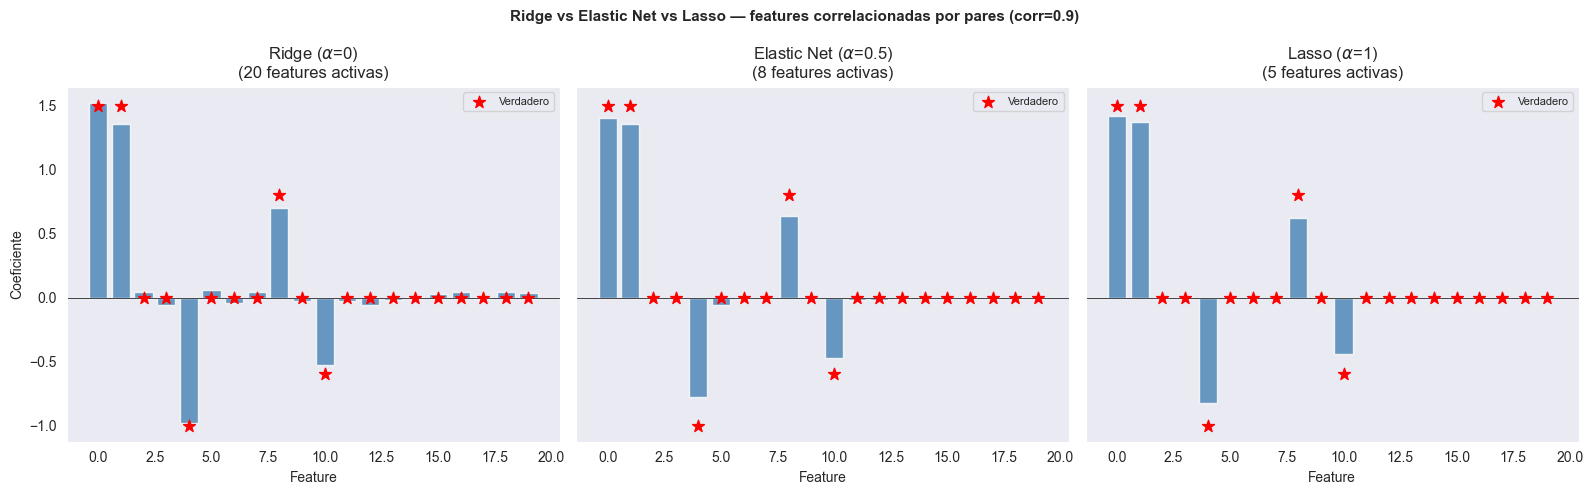

Modelo                         Features activas   MSE vs verdadero
------------------------------------------------------------------
Ridge ($a$=0)                                20             0.0031
Elastic Net ($a$=0.5)                         8             0.0062
Lasso ($a$=1)                                 5             0.0055


In [18]:
# Elastic Net vs Ridge vs Lasso con features correlacionadas
np.random.seed(42)
T4, p4 = 150, 20

# Crear features con correlación por bloques
Sigma = np.eye(p4)
for i in range(0, 8, 2):   # pares con correlación 0.9
    Sigma[i, i+1] = Sigma[i+1, i] = 0.9
X4 = np.random.multivariate_normal(np.zeros(p4), Sigma, T4)

beta4 = np.zeros(p4)
beta4[[0, 1, 4, 8, 10]] = [1.5, 1.5, -1.0, 0.8, -0.6]
y4 = X4 @ beta4 + 0.4 * np.random.randn(T4)
X4s = (X4 - X4.mean(0)) / X4.std(0)

lam4 = 0.1
models4 = {
    'Ridge ($\\alpha$=0)':         Ridge(alpha=lam4).fit(X4s, y4),
    'Elastic Net ($\\alpha$=0.5)': ElasticNet(alpha=lam4, l1_ratio=0.5, max_iter=10000).fit(X4s, y4),
    'Lasso ($\\alpha$=1)':         Lasso(alpha=lam4, max_iter=10000).fit(X4s, y4),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
x_pos4 = np.arange(p4)

for ax, (name, model) in zip(axes, models4.items()):
    coefs4 = model.coef_
    # Color basado en coeficientes ESTIMADOS, no en los verdaderos
    colors4 = ['steelblue' if np.abs(coefs4[j]) > 1e-6 else 'lightgray' for j in range(p4)]
    ax.bar(x_pos4, coefs4, color=colors4, alpha=0.8)
    ax.scatter(x_pos4, beta4, color='red', marker='*', s=80, zorder=5, label='Verdadero')
    ax.axhline(0, color='k', lw=0.5)
    n_act = np.sum(np.abs(coefs4) > 1e-6)
    ax.set_title(f'{name}\n({n_act} features activas)')
    ax.set_xlabel('Feature')
    if ax is axes[0]: ax.set_ylabel('Coeficiente')
    ax.legend(fontsize=8)

plt.suptitle('Ridge vs Elastic Net vs Lasso — features correlacionadas por pares (corr=0.9)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Modelo':<30} {'Features activas':>16} {'MSE vs verdadero':>18}")
print('-' * 66)
for name, model in models4.items():
    n_act = np.sum(np.abs(model.coef_) > 1e-6)
    mse = np.mean((model.coef_ - beta4)**2)
    print(f"{name.replace(chr(92)+'alpha', 'a'):<30} {n_act:>16} {mse:>18.4f}")

El gráfico compara la recuperación de coeficientes de Ridge, Elastic Net y Lasso en un escenario con features correlacionadas por pares ($\text{corr} = 0.9$). Las estrellas rojas indican los coeficientes verdaderos 
$\beta^*$, de los cuales solo 5 son distintos de cero sobre un total de 20 variables.

* *Panel izquierdo — Ridge ($\alpha = 0$, 20 features activas):* Ridge mantiene todos los coeficientes distintos de cero, incluyendo las 15 variables irrelevantes. Al no poder anular coeficientes, distribuye la señal entre todas las features correlacionadas, lo que dificulta la interpretación y produce estimaciones alejadas de $\beta^*$ en las variables sin efecto real.

* *Panel central — Elastic Net ($\alpha = 0.5$, 8 features activas):* Elastic Net reduce el modelo a 8 variables activas, eliminando la mayoría de las irrelevantes y recuperando razonablemente bien los coeficientes verdaderos. Al combinar penalización $\ell_1$ y $\ell_2$, tiende a seleccionar conjuntamente las variables correlacionadas en lugar de elegir una arbitrariamente.

* *Panel derecho — Lasso ($\alpha = 1$, 5 features activas):* Lasso logra la mayor sparsidad al identificar exactamente 5 features activas, coincidiendo con el número de variables verdaderas. Sin embargo, en presencia de alta correlación entre features, la selección puede ser inestable: ante dos variables igualmente correlacionadas con el residuo, Lasso tiende a elegir una de forma arbitraria.

En conjunto, el gráfico ilustra el \textit{trade-off} entre sparsidad e interpretabilidad con features correlacionadas: Ridge es estable pero no selecciona, Lasso selecciona pero puede ser inestable, y Elastic Net ofrece un balance entre ambas propiedades, siendo la opción más robusta cuando las variables presentan correlación alta entre sí.

## 🐞 Validación Temporal: Walk-Forward y OOT

### El Problema del Leakage Temporal

En series de tiempo, usar `KFold(shuffle=True)` **contamina el futuro con el pasado**:

$$\underbrace{\text{Datos del futuro en train}}_{\text{leakage}} \;\Rightarrow\; \underbrace{\text{métricas demasiado optimistas}}_{\text{overfitting implícito}}$$

**📌 Observacion:** El test siempre debe ser temporalmente posterior al train.

### TimeSeriesSplit (Expanding Window)

Con $K$ folds, el split $k$ tiene:
- **Train:** $[1, \ldots, t_k]$ — ventana creciente
- **Gap:** $[t_k+1, \ldots, t_k + g]$ — período de protección
- **Test:** $[t_k + g + 1, \ldots, t_{k+1}]$ — siempre futuro

### Gap y Horizonte de Predicción

Cuando el target $y_t = f(r_{t+1}, \ldots, r_{t+h})$ usa un horizonte $h$:

$$\text{Gap} \geq h \quad \text{para evitar que labels del train usen datos del test}$$

### Checklist Anti-Leakage

1. **Target alineado:** `y = returns.shift(-h)` (target futuro, nunca `.shift(h)`)
2. **Features solo con datos pasados:** lags y rolling con `min_periods`
3. **Scaler dentro del pipeline** (se fittea solo en train de cada fold)
4. **Tuning de $\lambda$ dentro del CV temporal** (nunca usar el OOT para seleccionar $\lambda$)
5. **OOT final separado** antes de cualquier modelado

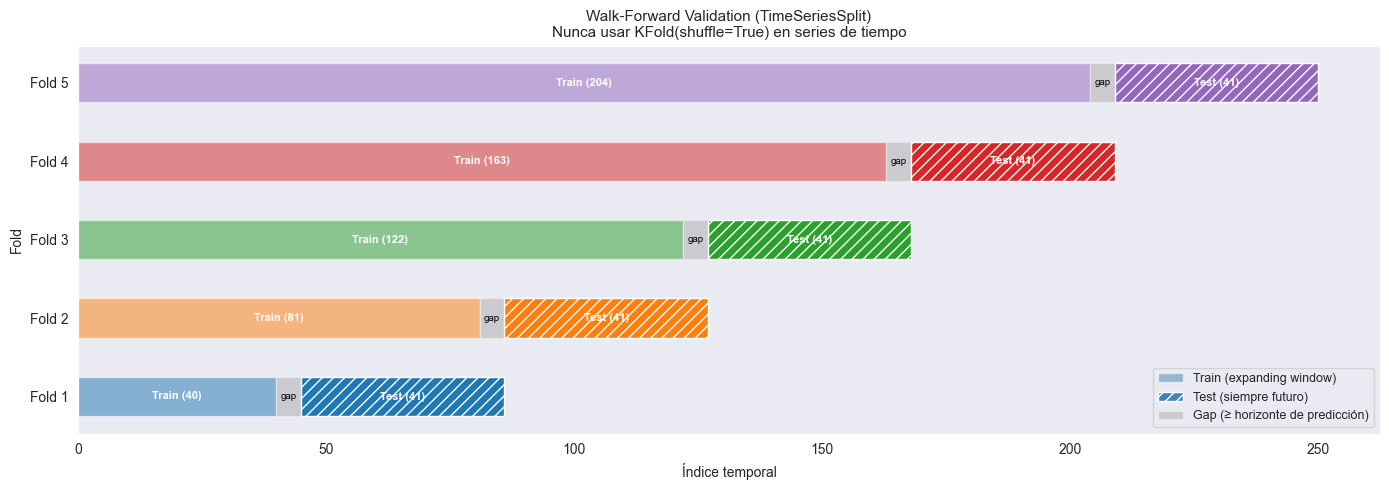

Tamaños por fold:
  Fold 1: Train=  40 | Gap | Test=  41
  Fold 2: Train=  81 | Gap | Test=  41
  Fold 3: Train= 122 | Gap | Test=  41
  Fold 4: Train= 163 | Gap | Test=  41
  Fold 5: Train= 204 | Gap | Test=  41


In [19]:
# Visualización de Walk-Forward splits
T_vis = 250
tscv_vis = TimeSeriesSplit(n_splits=5, gap=5)
X_vis = np.zeros((T_vis, 1))

fig, ax = plt.subplots(figsize=(14, 5))

palette = plt.cm.tab10.colors

for fold, (tr, te) in enumerate(tscv_vis.split(X_vis)):
    color = palette[fold]
    # Train
    ax.barh(fold, len(tr), left=tr[0], height=0.5, color=color, alpha=0.5)
    ax.text(tr[0] + len(tr)/2, fold, f'Train ({len(tr)})',
            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    # Gap
    gap_start = tr[-1] + 1
    gap_len = te[0] - gap_start
    if gap_len > 0:
        ax.barh(fold, gap_len, left=gap_start, height=0.5, color='gray', alpha=0.3)
        ax.text(gap_start + gap_len/2, fold, 'gap', ha='center', va='center', fontsize=7, color='black')
    # Test
    ax.barh(fold, len(te), left=te[0], height=0.5, color=color, alpha=1.0, hatch='///')
    ax.text(te[0] + len(te)/2, fold, f'Test ({len(te)})',
            ha='center', va='center', fontsize=8, fontweight='bold', color='white')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.5, label='Train (expanding window)'),
    Patch(facecolor='steelblue', alpha=1.0, hatch='///', label='Test (siempre futuro)'),
    Patch(facecolor='gray', alpha=0.3, label='Gap (≥ horizonte de predicción)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlabel('Índice temporal')
ax.set_ylabel('Fold')
ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_title('Walk-Forward Validation (TimeSeriesSplit)\n'
             'Nunca usar KFold(shuffle=True) en series de tiempo', fontsize=11)
plt.tight_layout()
plt.show()

print("Tamaños por fold:")
for i, (tr, te) in enumerate(tscv_vis.split(X_vis)):
    print(f"  Fold {i+1}: Train={len(tr):>4} | Gap | Test={len(te):>4}")

## 🪲 Aplicación A: Predicción de Retorno $r_{t+1}$

### Definición del Problema

Sea $P_t$ el precio ajustado. El retorno simple:
$$r_{t+1} = \frac{P_{t+1} - P_t}{P_t}$$

**Objetivo:** predecir $y_t = r_{t+1}$ con información disponible hasta $t$.

> **Alineación crítica:** Si `returns = prices.pct_change()`, el target es `returns.shift(-1)` y las features usan `returns.shift(k)` con $k \geq 1$.

### Features Seguras (Sin Futuro)

$$x_t = \Big[r_{t-1},\; r_{t-2},\; r_{t-3},\; \text{mom}_t^{(5)},\; \text{mom}_t^{(20)},\; \sigma_t^{(5)},\; \sigma_t^{(20)}\Big]$$

donde:
$$\text{mom}_t^{(k)} = \frac{P_{t-1}}{P_{t-1-k}} - 1, \qquad \sigma_t^{(w)} = \operatorname{std}(r_{t-1},\; r_{t-2},\; \ldots,\; r_{t-w})$$

### Métricas Recomendadas

- **MAE / RMSE** por fold: magnitud del error de predicción
- **Spearman $\rho$**: si el uso es ranking (long-short), más relevante que el error absoluto
- **IC (Information Coefficient)**: $\rho(\hat{y}_t, y_t)$ — reportar por fold para evaluar estabilidad

In [ ]:
# Datos del Spy500
ticker = yf.Ticker("SPY")
prices_raw = ticker.history(start="2018-01-01", end="2024-01-01")['Close']
prices_raw.index = prices_raw.index.tz_localize(None)
print(f"Datos reales SPY: {len(prices_raw)} obs")


# Feature engineering sin leakage
def build_return_features(prices):
    r = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    for lag in [1, 2, 3]:
        df[f'ret_lag{lag}'] = r.shift(lag)
    for w in [5, 20]:
        df[f'mom_{w}'] = prices.shift(1).pct_change(w)
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()
    df['target'] = r.shift(-1)      # retorno de mañana
    return df.dropna()

df_ret = build_return_features(prices_raw)
X_ret = df_ret.drop(columns=['target'])
y_ret = df_ret['target']

n_oot = int(len(df_ret) * 0.2)
X_train_ret, y_train_ret = X_ret.iloc[:-n_oot], y_ret.iloc[:-n_oot]
X_oot_ret,   y_oot_ret   = X_ret.iloc[-n_oot:], y_ret.iloc[-n_oot:]

print(f"Features: {X_ret.columns.tolist()}")
print(f"Train: {len(X_train_ret)} | OOT: {len(X_oot_ret)}")
print(f"\nEstadísticas del target:")
print(y_ret.describe())

Datos reales SPY: 1509 obs
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'mom_5', 'rvol_5', 'mom_20', 'rvol_20']
Train: 1190 | OOT: 297

Estadísticas del target:
count    1487.000000
mean        0.000504
std         0.012917
min        -0.109424
25%        -0.004980
50%         0.000738
75%         0.006979
max         0.090603
Name: target, dtype: float64


In [ ]:
# Pipeline Ridge vs Lasso vs Elastic Net para predicción de retornos
tscv_ret = TimeSeriesSplit(n_splits=5, gap=3)

def run_grid(estimator, param_grid, X_train, y_train, cv):
    pipe = Pipeline(
        [('scaler', StandardScaler()), 
         ('model', estimator)
         ]
    )
    
    grid = GridSearchCV(pipe, param_grid,
                        scoring='neg_mean_absolute_error',
                        cv=cv, n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    return grid

specs_ret = {
    'OLS':        (LinearRegression(), {}),
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000), {
                  'model__alpha':    np.logspace(-5, 0, 12),
                  'model__l1_ratio': [0.1, 0.5, 0.9]}),
}

fitted_ret = {}
print(f"{'Modelo':<12} {'λ óptimo':>12} {'MAE(CV)':>10} {'Coefs activos':>14}")
print('-' * 52)

for name, (est, params) in specs_ret.items():
    grid = run_grid(est, params, X_train_ret, y_train_ret, tscv_ret)
    fitted_ret[name] = grid
    mae_cv = -grid.best_score_
    coef = grid.best_estimator_.named_steps['model'].coef_
    n_act = int(np.sum(np.abs(coef) > 1e-8))
    alpha_str = f"{grid.best_params_.get('model__alpha', float('nan')):.4f}" \
                if 'model__alpha' in grid.best_params_ else 'N/A'
    print(f"{name:<12} {alpha_str:>12} {mae_cv:>10.6f} {n_act:>14}")

Modelo           λ óptimo    MAE(CV)  Coefs activos
----------------------------------------------------
OLS                   N/A   0.009696              7
Ridge            100.0000   0.009473              7
Lasso              0.0023   0.009304              0
ElasticNet         0.0019   0.009302              0


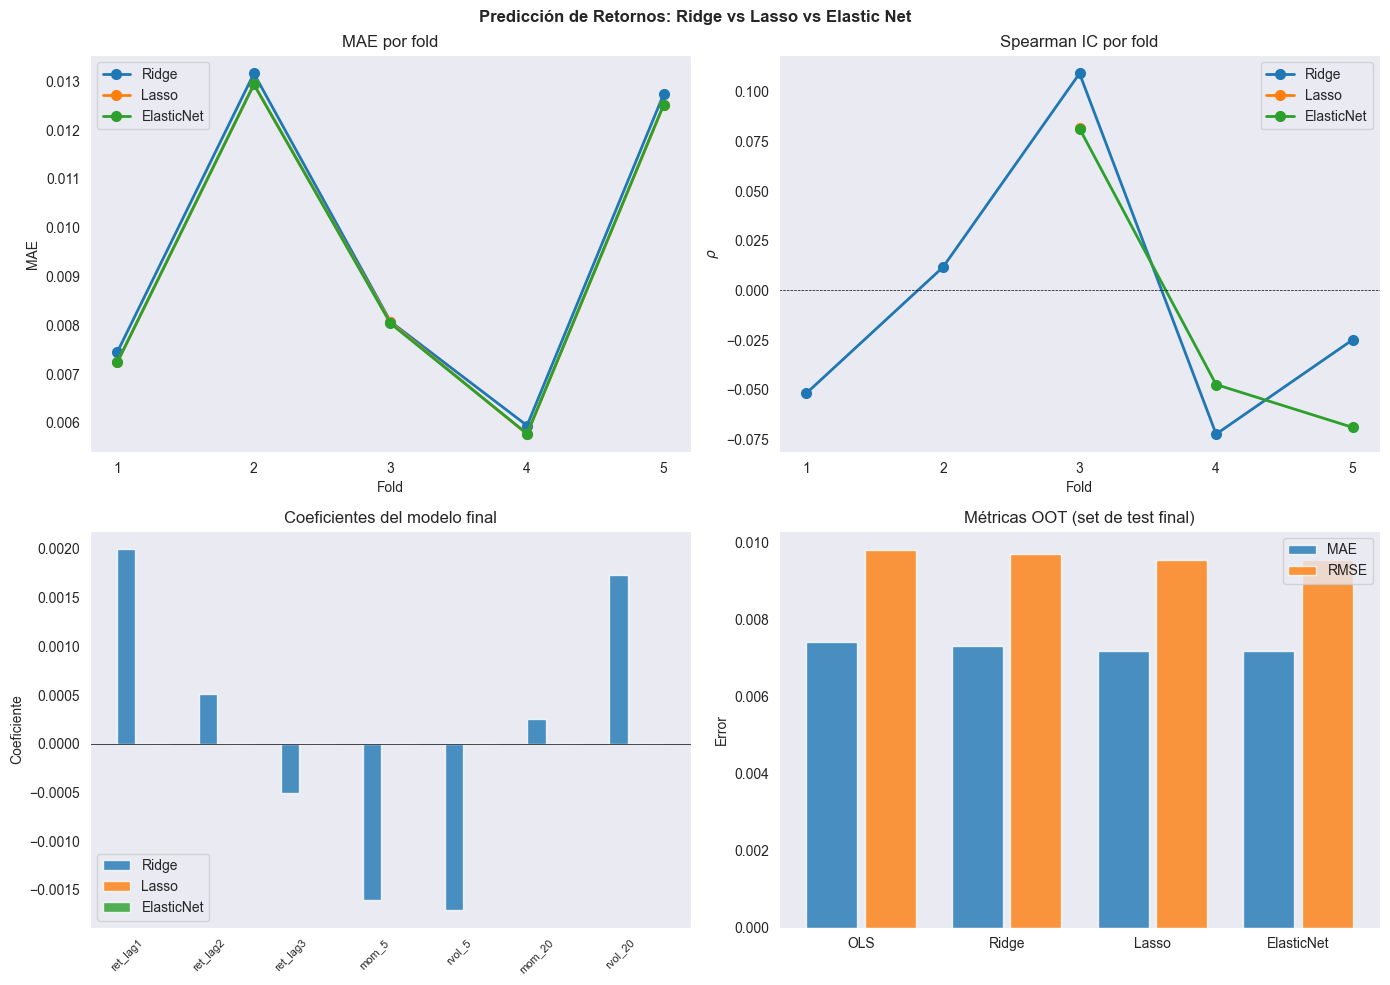


=== Métricas OOT ===
                 MAE      RMSE  Spearman
Modelo                                  
OLS         0.007413  0.009803 -0.033445
Ridge       0.007309  0.009698 -0.032560
Lasso       0.007173  0.009533       NaN
ElasticNet  0.007173  0.009533       NaN


In [22]:
# Análisis por fold + evaluación OOT
def fold_analysis(estimator, X, y, cv):
    rows = []
    for i, (tr, te) in enumerate(cv.split(X)):
        m = clone(estimator); m.fit(X.iloc[tr], y.iloc[tr])
        pred = m.predict(X.iloc[te])
        rows.append({
            'fold': i+1,
            'mae': mean_absolute_error(y.iloc[te], pred),
            'spearman': stats.spearmanr(y.iloc[te], pred).statistic,
            'periodo': X.index[te[0]].strftime('%Y-%m')
        })
    return pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MAE por fold
ax = axes[0, 0]
for name, grid in fitted_ret.items():
    if name == 'OLS': continue
    fd = fold_analysis(grid.best_estimator_, X_train_ret, y_train_ret, tscv_ret)
    ax.plot(fd['fold'], fd['mae'], 'o-', lw=2, ms=7, label=name)
ax.set_title('MAE por fold'); ax.set_xlabel('Fold'); ax.set_ylabel('MAE')
ax.legend(); ax.set_xticks(range(1, 6))

# Spearman IC por fold
ax = axes[0, 1]
for name, grid in fitted_ret.items():
    if name == 'OLS': continue
    fd = fold_analysis(grid.best_estimator_, X_train_ret, y_train_ret, tscv_ret)
    ax.plot(fd['fold'], fd['spearman'], 'o-', lw=2, ms=7, label=name)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_title('Spearman IC por fold'); ax.set_xlabel('Fold'); ax.set_ylabel(r'$\rho$')
ax.legend(); ax.set_xticks(range(1, 6))

# Coeficientes
ax = axes[1, 0]
feat_names = X_train_ret.columns.tolist()
x_f = np.arange(len(feat_names))
w = 0.22
offsets = [-w, 0, w]
for k, (name, grid) in enumerate([(n, g) for n, g in fitted_ret.items() if n != 'OLS']):
    coef = grid.best_estimator_.named_steps['model'].coef_
    ax.bar(x_f + offsets[k], coef, width=w, label=name, alpha=0.8)
ax.set_xticks(x_f); ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Coeficientes del modelo final'); ax.set_ylabel('Coeficiente'); ax.legend()

# Métricas OOT
ax = axes[1, 1]
oot_rows = []
for name, grid in fitted_ret.items():
    pred = grid.predict(X_oot_ret)
    oot_rows.append({'Modelo': name,
                     'MAE': mean_absolute_error(y_oot_ret, pred),
                     'RMSE': np.sqrt(mean_squared_error(y_oot_ret, pred)),
                     'Spearman': stats.spearmanr(y_oot_ret, pred).statistic})
oot_df = pd.DataFrame(oot_rows).set_index('Modelo')

x_oot = np.arange(len(oot_df))
ax.bar(x_oot - 0.2, oot_df['MAE'], width=0.35, label='MAE', alpha=0.8)
ax.bar(x_oot + 0.2, oot_df['RMSE'], width=0.35, label='RMSE', alpha=0.8)
ax.set_xticks(x_oot); ax.set_xticklabels(oot_df.index)
ax.set_title('Métricas OOT (set de test final)'); ax.set_ylabel('Error'); ax.legend()

plt.suptitle('Predicción de Retornos: Ridge vs Lasso vs Elastic Net', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n=== Métricas OOT ===")
print(oot_df.round(6).to_string())

El gráfico presenta cuatro perspectivas del desempeño de Ridge, Lasso y 
Elastic Net en la predicción de retornos futuros $r_{t+1}$.


* *Panel superior izquierdo — MAE por fold:* el error absoluto medio es prácticamente idéntico entre los tres modelos en todos los folds, lo que refleja que en presencia de señal débil (bajo SNR), la elección del método de regularización tiene poco impacto sobre la magnitud del error de predicción. Se observa además alta variabilidad entre folds, evidenciando la no estacionariedad de la serie.

* *Panel superior derecho — Spearman IC por fold:* el coeficiente de correlación de Spearman $\rho$ entre predicciones y retornos reales oscila entre $-0.07$ y $0.10$, cambiando de signo entre folds. Esto indica que la dirección de la señal es inestable a lo largo del tiempo y que ningún modelo logra una señal consistentemente positiva, lo cual es esperado en retornos de activos financieros.

* *Panel inferior izquierdo — Coeficientes del modelo final:* Ridge mantiene todos los coeficientes activos, mientras que Lasso y Elastic Net los anulan casi completamente (barras de altura cero), seleccionando un modelo prácticamente nulo. Esto es consistente con un escenario de bajo SNR donde la penalización $\ell_1$ concluye que ninguna feature supera el umbral de relevancia $\lambda$.

* *Panel inferior derecho — Métricas OOT:* los cuatro modelos (OLS, Ridge, Lasso y Elastic Net) producen métricas MAE y RMSE casi indistinguibles en el conjunto de test final. La ausencia de mejora sustancial respecto a OLS confirma que la señal predictiva en los retornos diarios es extremadamente débil, y que la regularización, si bien evita el sobreajuste, no puede crear señal donde no existe.

En conjunto, los cuatro paneles ilustran un resultado habitual en la predicción de retornos financieros: los modelos regularizados no mejoran significativamente el error absoluto respecto a OLS, pero sí producen modelos más parsimoniosos y estables, lo cual es valioso para la construcción de señales de inversión robustas fuera de muestra.


## 🐝 Aplicación B: Forecast de Volatilidad Realizada

### Target: Volatilidad Realizada

La volatilidad realizada a $h$ días adelante:
$$\text{RV}_{t,h} = \sqrt{\sum_{i=1}^{h} r_{t+i}^2}$$

Define $y_t = \text{RV}_{t,h}$. El target usa retornos **futuros** $r_{t+1}, \ldots, r_{t+h}$, por lo que el gap debe ser $\geq h$.

### Features: Modelo HAR-like

El modelo HAR (Corsi, 2009) usa lags de volatilidad a distintas escalas:
$$\text{RV}_{t,h} \approx \beta_0 + \beta_d\,\text{RV}_{t-1}^{(1)} + \beta_w\,\text{RV}_{t-1}^{(5)} + \beta_m\,\text{RV}_{t-1}^{(22)} + \varepsilon_t$$

Features extendidas para regularización:
$$x_t = \Big[\sigma_{t-1}^{(1)},\; \sigma_{t-1}^{(5)},\; \sigma_{t-1}^{(22)},\; \sigma_{t-1}^{(60)},\; |r_{t-1}|,\; r_{t-1}^2,\; \text{mom}_{t-1}^{(5)},\; \log\sigma_{t-1}^{(22)}\Big]$$

### Métricas

- **MAE / RMSE** por fold en niveles
- **R²** (fracción de varianza explicada)
- **Gráfico de error por tiempo** para detectar drift o cambio de régimen

### Uso Financiero del Forecast de Volatilidad

| Aplicación | Cómo usar $\hat{\text{RV}}_{t,h}$ |
|-----------|-----------------------------------|
| **Position sizing** | Reducir exposición cuando $\hat{\text{RV}}$ sube |
| **VaR condicional** | $\text{VaR}_{t,h}^\alpha \approx z_\alpha \cdot \hat{\text{RV}}_{t,h}$ |
| **Cobertura dinámica** | Ajustar delta-hedge según vol predicha |
| **Primas de riesgo** | Input para modelos de pricing o factor models |

In [23]:
# Feature engineering para volatilidad
h_vol = 5   # horizonte: 5 días hábiles

def build_vol_features(prices, h=5):
    r = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    # w=1: rolling(1).std() siempre es NaN (ddof=1 con 1 obs) → usar |r| como proxy
    df['rvol_1d'] = r.shift(1).abs() * np.sqrt(252)
    for w in [5, 22, 60]:
        df[f'rvol_{w}d'] = r.shift(1).rolling(w, min_periods=w).std() * np.sqrt(252)
    df['abs_ret']    = np.abs(r.shift(1))
    df['sq_ret']     = r.shift(1) ** 2
    df['mom_5']      = prices.shift(1).pct_change(5)
    df['log_rvol22'] = np.log(df['rvol_22d'].clip(lower=1e-6))
    # Target: volatilidad realizada de los próximos h días
    rv_fwd = r.rolling(h).std().shift(-h) * np.sqrt(252)
    df['target'] = rv_fwd
    return df.dropna()

df_vol = build_vol_features(prices_raw, h=h_vol)
X_vol = df_vol.drop(columns=['target'])
y_vol = df_vol['target']

n_oot_vol = int(len(df_vol) * 0.2)
X_train_vol, y_train_vol = X_vol.iloc[:-n_oot_vol], y_vol.iloc[:-n_oot_vol]
X_oot_vol,   y_oot_vol   = X_vol.iloc[-n_oot_vol:], y_vol.iloc[-n_oot_vol:]

print(f"Observaciones totales: {len(df_vol)} | Train: {len(X_train_vol)} | OOT: {len(X_oot_vol)}")
print(f"Features: {X_vol.columns.tolist()}\n")

tscv_vol = TimeSeriesSplit(n_splits=5, gap=h_vol)

specs_vol = {
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000), {
                  'model__alpha':    np.logspace(-5, 0, 12),
                  'model__l1_ratio': [0.1, 0.5, 0.9]}),
}

fitted_vol = {}
print(f"{'Modelo':<12} {'\u03bb óptimo':>12} {'MAE(CV)':>12}")
print('-' * 40)
for name, (est, params) in specs_vol.items():
    grid = run_grid(est, params, X_train_vol, y_train_vol, tscv_vol)
    fitted_vol[name] = grid
    alpha_str = f"{grid.best_params_.get('model__alpha', 0):.4f}"
    print(f"{name:<12} {alpha_str:>12} {-grid.best_score_:>12.6f}")

print(f"\nHorizonte h={h_vol}d | Gap={h_vol} | Features: {X_vol.shape[1]}")

Observaciones totales: 1443 | Train: 1155 | OOT: 288
Features: ['rvol_1d', 'rvol_5d', 'rvol_22d', 'rvol_60d', 'abs_ret', 'sq_ret', 'mom_5', 'log_rvol22']

Modelo           λ óptimo      MAE(CV)
----------------------------------------
Ridge             11.2884     0.070689
Lasso              0.0004     0.070508
ElasticNet         0.0007     0.070563

Horizonte h=5d | Gap=5 | Features: 8


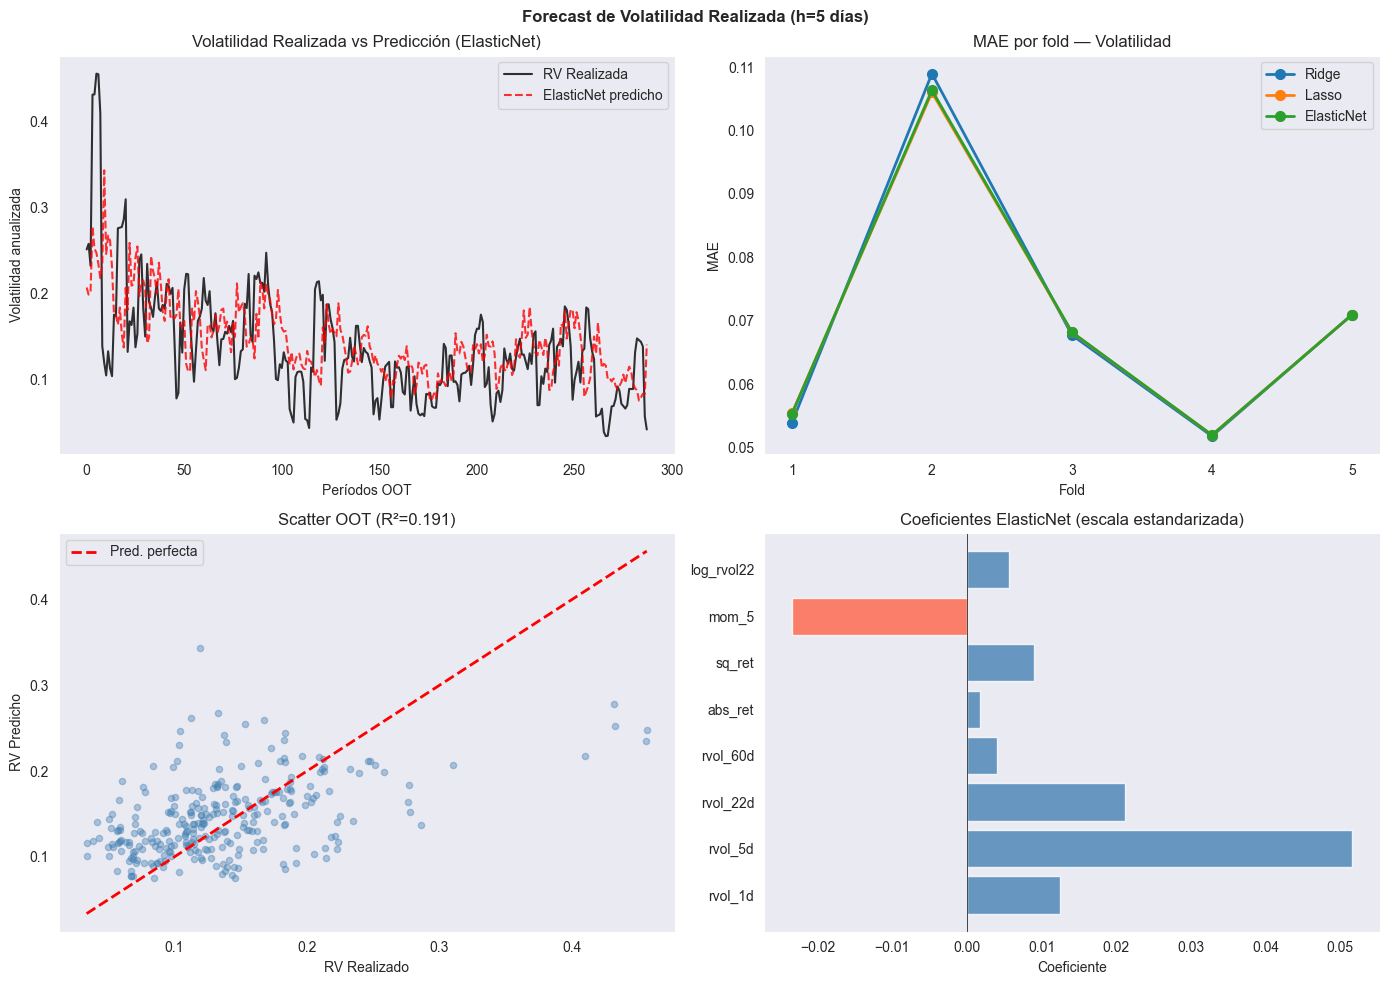


=== Métricas OOT — Volatilidad ===
Ridge       : MAE=0.04384 | RMSE=0.05904 | R²=0.194
Lasso       : MAE=0.04391 | RMSE=0.05914 | R²=0.191
ElasticNet  : MAE=0.04390 | RMSE=0.05914 | R²=0.191


In [24]:
# Visualización: forecast de volatilidad
best_vol = 'ElasticNet'
pred_vol_oot = fitted_vol[best_vol].predict(X_oot_vol)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Serie temporal: predicho vs realizado
ax = axes[0, 0]
ax.plot(y_oot_vol.values, color='black', lw=1.5, alpha=0.8, label='RV Realizada')
ax.plot(pred_vol_oot, color='red', lw=1.5, ls='--', alpha=0.8, label=f'{best_vol} predicho')
ax.set_title(f'Volatilidad Realizada vs Predicción ({best_vol})')
ax.set_xlabel('Períodos OOT'); ax.set_ylabel('Volatilidad anualizada')
ax.legend()

# MAE por fold para cada modelo
ax = axes[0, 1]
for name, grid in fitted_vol.items():
    fd = fold_analysis(grid.best_estimator_, X_train_vol, y_train_vol, tscv_vol)
    ax.plot(fd['fold'], fd['mae'], 'o-', lw=2, ms=7, label=name)
ax.set_title('MAE por fold — Volatilidad'); ax.set_xlabel('Fold'); ax.set_ylabel('MAE')
ax.legend(); ax.set_xticks(range(1, 6))

# Scatter predicho vs realizado
ax = axes[1, 0]
ax.scatter(y_oot_vol, pred_vol_oot, alpha=0.4, s=20, color='steelblue')
lims = [min(y_oot_vol.min(), pred_vol_oot.min()),
        max(y_oot_vol.max(), pred_vol_oot.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Pred. perfecta')
r2_v = r2_score(y_oot_vol, pred_vol_oot)
ax.set_xlabel('RV Realizado'); ax.set_ylabel('RV Predicho')
ax.set_title(f'Scatter OOT (R²={r2_v:.3f})'); ax.legend()

# Coeficientes del modelo de volatilidad
ax = axes[1, 1]
coef_v = fitted_vol[best_vol].best_estimator_.named_steps['model'].coef_
colors_v = ['tomato' if c < 0 else 'steelblue' for c in coef_v]
ax.barh(X_vol.columns.tolist(), coef_v, color=colors_v, alpha=0.8)
ax.axvline(0, color='k', lw=0.5)
ax.set_title(f'Coeficientes {best_vol} (escala estandarizada)')
ax.set_xlabel('Coeficiente')

plt.suptitle(f'Forecast de Volatilidad Realizada (h={h_vol} días)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n=== Métricas OOT — Volatilidad ===")
for name, grid in fitted_vol.items():
    pred = grid.predict(X_oot_vol)
    print(f"{name:<12}: MAE={mean_absolute_error(y_oot_vol, pred):.5f} "
          f"| RMSE={np.sqrt(mean_squared_error(y_oot_vol, pred)):.5f} "
          f"| R²={r2_score(y_oot_vol, pred):.3f}")

El gráfico presenta cuatro perspectivas del desempeño de Elastic Net en el  forecast de volatilidad realizada a un horizonte de $h = 5$ días hábiles.

* *Panel superior izquierdo — Volatilidad Realizada vs Predicción:* la línea roja punteada (predicción) sigue de forma razonable la dinámica de la volatilidad realizada (línea negra), capturando los  principales regímenes de alta y baja volatilidad. El modelo suaviza los picos extremos, lo cual es esperable dado que la regularización encoge los coeficientes y modera las predicciones en los colas de la distribución.

* *Panel superior derecho — MAE por fold:* el error absoluto medio es prácticamente idéntico entre Ridge, Lasso y Elastic Net en todos los folds, lo que sugiere que la elección del método de regularización no  es determinante para la precisión del forecast de volatilidad. Se observa un pico de error en el fold 2, asociado a un período de mayor volatilidad en la muestra de entrenamiento.

* *Panel inferior izquierdo — Scatter OOT ($R^2 = 0.191$):* el diagrama de dispersión entre volatilidad realizada y predicha muestra una correlación positiva con $R^2 = 0.191$, indicando que el modelo explica aproximadamente el $19\%$ de la varianza de la volatilidad futura. Este nivel de ajuste es considerado alto en el contexto de pronóstico de volatilidad, donde valores de $R^2$ entre $0.10$ y $0.25$ son habituales en la literatura.

* *Panel inferior derecho — Coeficientes Elastic Net:* las variables de volatilidad pasada a distintas escalas temporales *rvol_5d*, *rvol_22d*, *rvol_60d* reciben los coeficientes positivos más grandes, confirmando la persistencia de la volatilidad. La variable *mom_5* presenta el único coeficiente negativo relevante, sugiriendo que períodos de momentum positivo reciente se asocian a menor volatilidad futura. Las variables *abs_ret* y *sq_ret* aportan señal adicional a través de la magnitud del retorno más reciente.

En conjunto, los cuatro paneles muestran que el forecast de volatilidad con modelos regularizados es sustancialmente más informativo que el forecast de retornos: el $R^2 = 0.191$ contrasta con el $R^2 \approx 0$ obtenido en la predicción de retornos, lo que es consistente con la literatura financiera — la volatilidad es persistente y predecible, mientras que los retornos son cercanos a un proceso de ruido blanco.
